In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_circles


National Institute of Diabetes and Digestive and Kidney Diseases
2-Hour serum insulin (muU/ml) microunit/ml
Triceps skin fold thickness (mm)
Precission=how many of true positive are detected among all true detected cases tp/tp+fp
Recall=how many actual cases are detected tp/tp+fn
f1 score is hamonic mean of precission and recall

In [2]:
data=pd.read_csv('/content/diabetes_dataset.csv')

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


DiabetesPedigreeFunction-It is a numeric value that estimates the genetic likelihood of diabetes based on family historyLow values (e.g., 0.1 – 0.5): Suggest a low genetic predisposition

High values (e.g., 1.0+): Indicate a higher chance of diabetes based on family history


It represents the triceps skinfold thickness measured in millimeters (mm).
This is a clinical measurement used to estimate body fat percentage by pinching the skin (usually the back of the upper arm) and measuring the thickness of the fold.

Plasma glucose concentration a 2 hours in an oral glucose tolerance test


In a 2-hour oral glucose tolerance test (OGTT), a plasma glucose concentration below 140 mg/dL (7.8 mmol/L) is considered normal. Levels between 140 and 199 mg/dL (7.8 to 11.1 mmol/L) indicate impaired glucose tolerance, and levels of 200 mg/dL (11.1 mmol/L) or higher are diagnostic of diabetes.


In [4]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


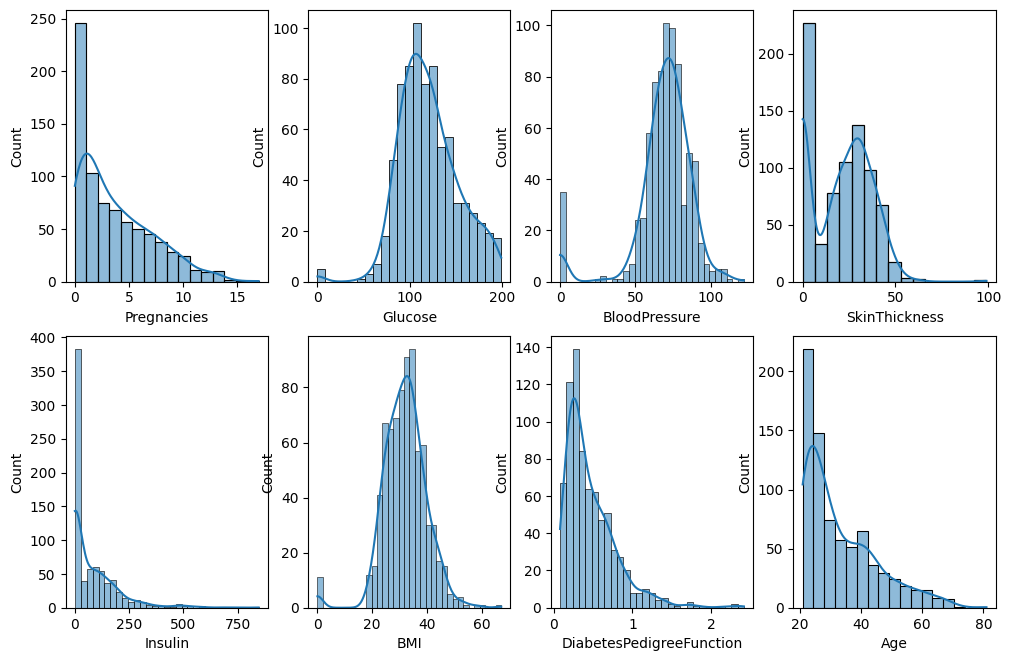

In [7]:
plt.figure(figsize=(12,12))
for i, col in enumerate(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']):
    plt.subplot(3, 4, i+1)
    sns.histplot(x=col,data=data,kde=True)
plt.show()

The Kernel Density Estimator (KDE) is a non-parametric way to estimate the probability density function (PDF) of a continuous random variable.

In [8]:
cols_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols_to_replace] = data[cols_to_replace].replace(0, np.nan)

In [9]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


#Missing values are replaced

In [10]:
def median_target(var):
    temp = data[data[var].notnull()]#take the value where var value in not null
    temp = temp[[var, 'Outcome']].groupby(['Outcome'])[[var]].median().reset_index()
    #then keep only var and output column then groupby basis on outcome then find its median and return it
    return temp

In [11]:
# The values to be given for incomplete observations are given the median value of people who are not sick and the median values of people who are sick.
columns = data.columns
columns = columns.drop("Outcome")
for i in columns:
    median_target(i)
    data.loc[(data['Outcome'] == 0 ) & (data[i].isnull()), i] = median_target(i)[i][0]
    data.loc[(data['Outcome'] == 1 ) & (data[i].isnull()), i] = median_target(i)[i][1]

In [12]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


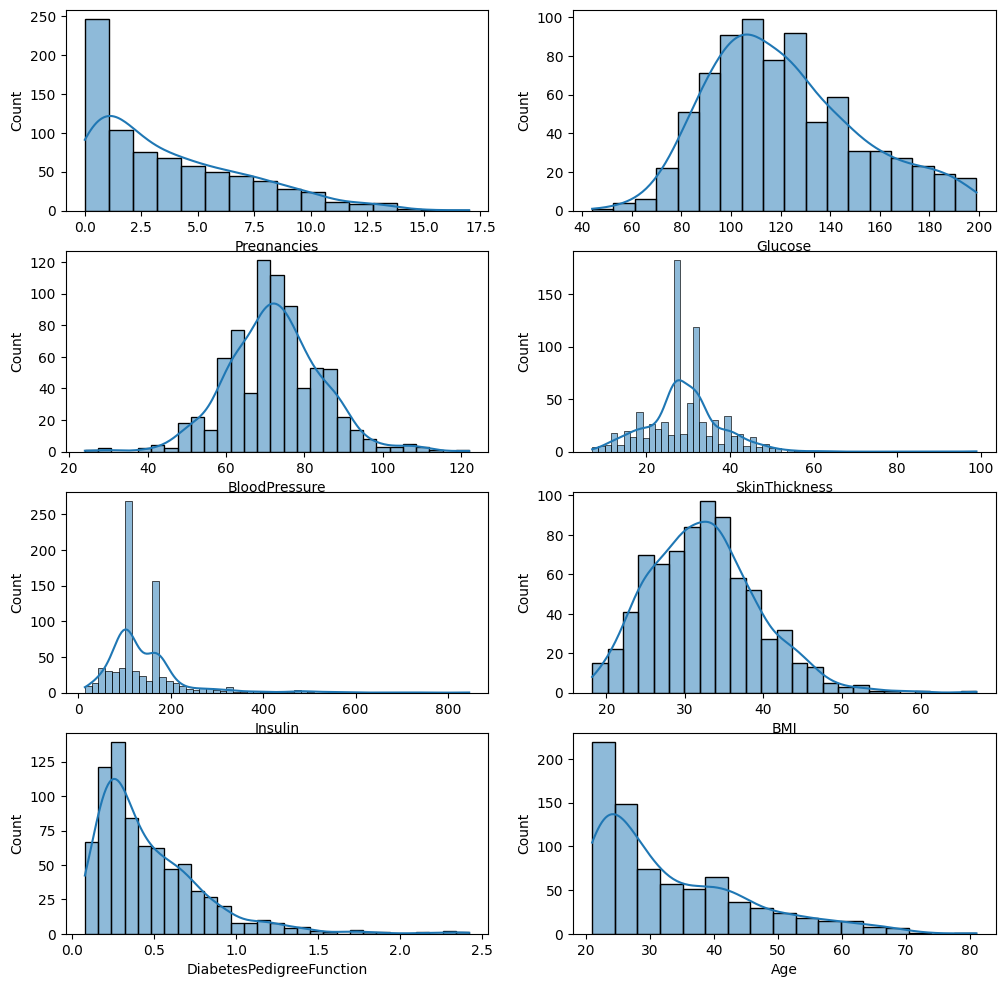

In [13]:
plt.figure(figsize=(12,12))
for i, col in enumerate(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']):
    plt.subplot(4, 2, i+1)
    sns.histplot(x=col,data=data,kde=True)
plt.show()

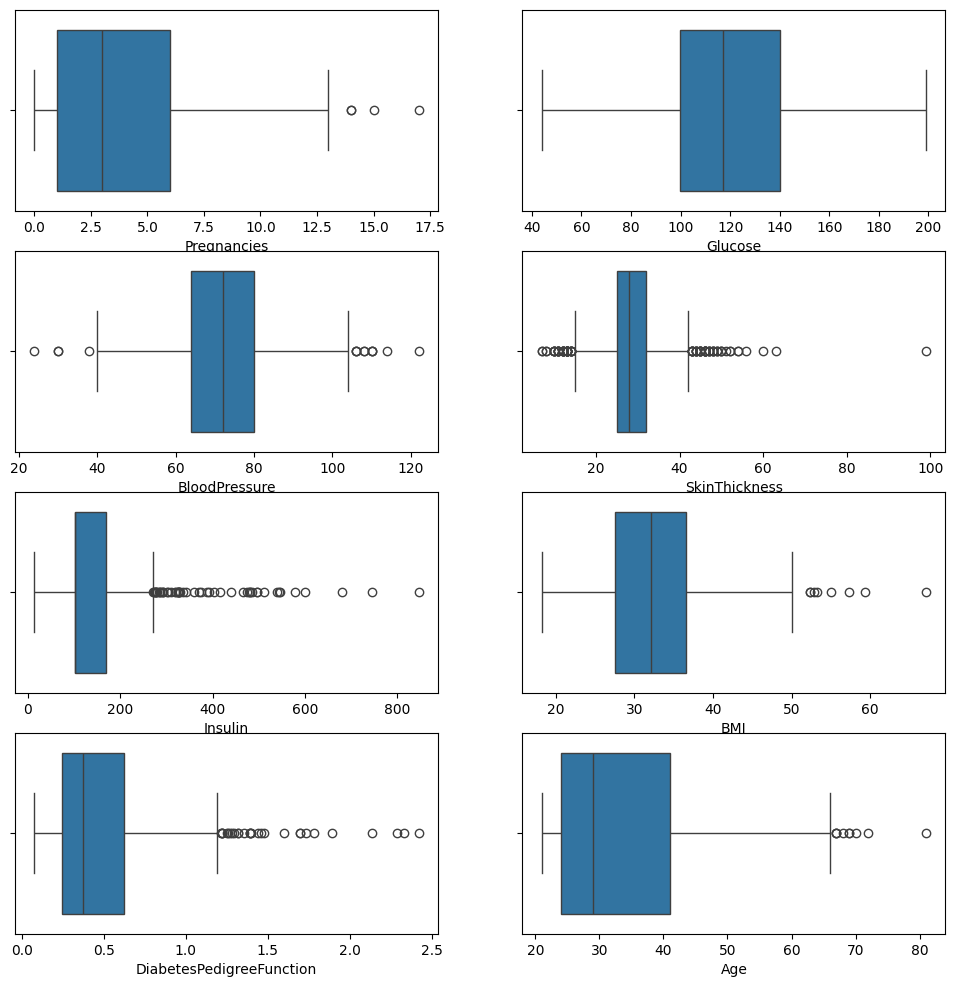

In [14]:
plt.figure(figsize=(12,12))
for i, col in enumerate(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x=col,data=data)
plt.show()

#Local Oulier Factor detection and removal  
##Accuracy Score 0,1 mean replace
stacking df adb gdbt final model xg boost   Ac.Score 0.8947</br>
GRadiant boosting Ac.Score:  0.8618</br>
Ada boost Ac.Score 0.8815</br>
Random Forest Ac.Score is  0.8815</br>
Xg boost  Ac.Score:  0.8947

In [15]:
data.shape

(768, 9)

In [16]:
# from sklearn.neighbors import LocalOutlierFactor
# lof =LocalOutlierFactor(n_neighbors= 10)
# lof.fit_predict(data)
# df_scores = lof.negative_outlier_factor_
# np.sort(df_scores)[0:50]
# threshold = np.sort(df_scores)[7]
# threshold
# outlier = df_scores > threshold
# data = data[outlier]

In [17]:
data.shape

(768, 9)

#Isolation Tree Out lier detection and removal
##Accuracy score 0,1 mean replace
stacking df adb gdbt final model xg boost  0.8947368421052632</br>
GRadiant boosting Test Accuracy:  0.8881578947368421</br>
Ada boost 0.8881578947368421</br>
Random Forest Accuracy Score for testing data is  0.881578947368421</br>
Xg boost Test Accuracy:  0.8881578947368421

In [18]:
#It work with calulating the min path length of each point with a many tree fromation
#the lowest the min that is the outlier

# from sklearn.ensemble import IsolationForest

# iso_forest = IsolationForest(
#     contamination=0.01,   # No of outlier that to be removed or detected
#     random_state=42       #always gives the same result
# )

# outliers = iso_forest.fit_predict(data)
# data = data[outliers == 1]
# print(f"New Shape: {data.shape}")


#IQR Metgode
##Accuracy Score
Model | Accuracy Score</br>
Random Forest (Tuned) | 0.88</br>
XGBoost (Tuned) | 0.90</br>
AdaBoost | 0.83</br>
Gradient Boosting | 0.87</br>
Stacked Ensemble Model | 0.90</br>
Balanced Random Forest | 0.87</br>

In [19]:

columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']

for col in columns:
    Q1 = data[col].quantile(0.25)#25 persentile
    Q3 = data[col].quantile(0.75)#75 persentile
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Keep only the rows within the IQR range
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

print("Shape after outlier removal:", data.shape)


Shape after outlier removal: (595, 9)


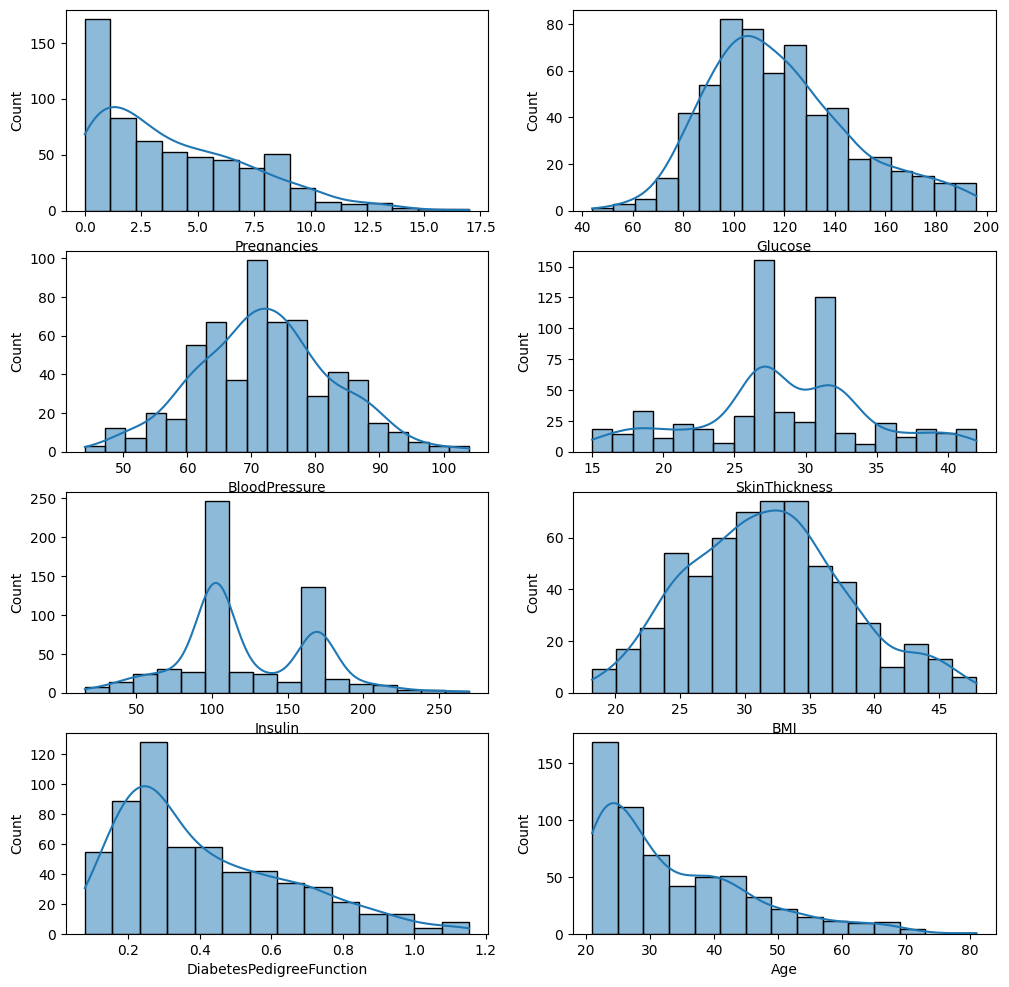

In [20]:
plt.figure(figsize=(12,12))
for i, col in enumerate(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']):
    plt.subplot(4, 2, i+1)
    sns.histplot(x=col,data=data,kde=True)
plt.show()

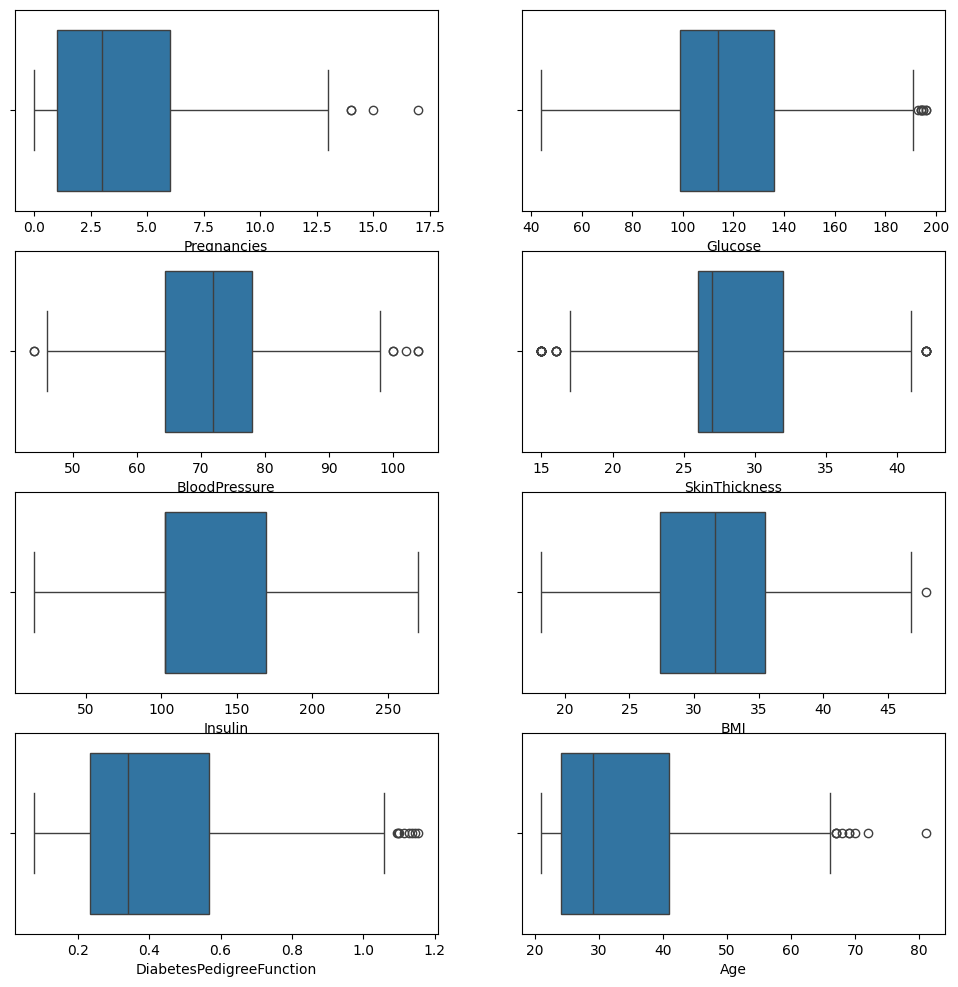

In [21]:
plt.figure(figsize=(12,12))
for i, col in enumerate(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x=col,data=data)
plt.show()

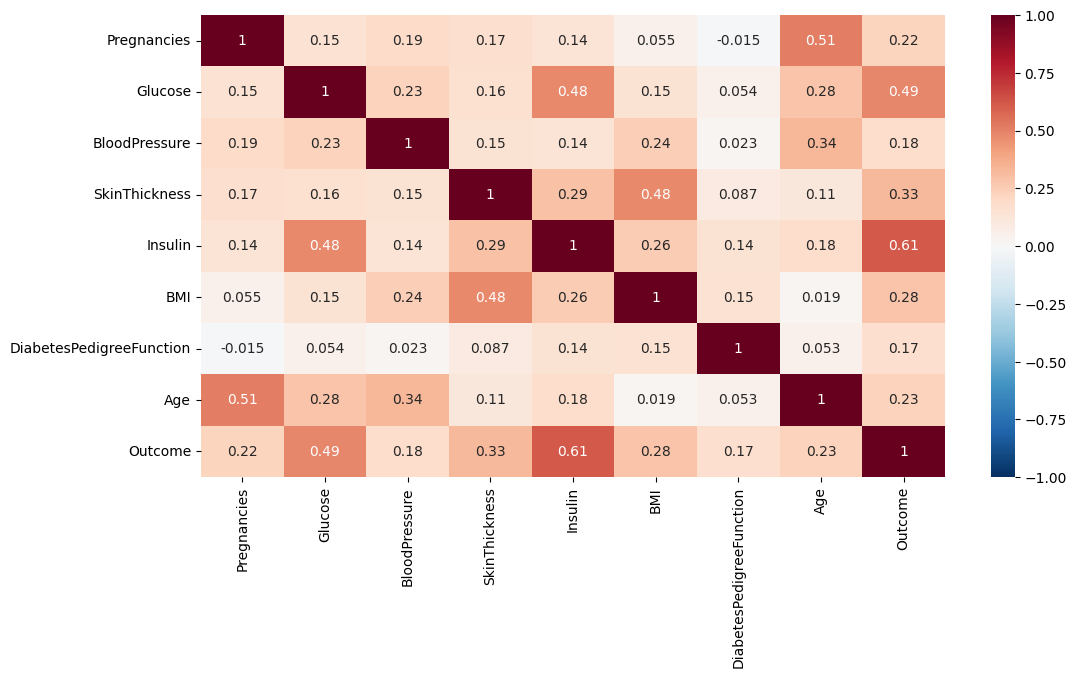

In [22]:
plt.figure(figsize=(12,6))
sns.heatmap(data.corr(), vmin=-1,center=0, cmap='RdBu_r',annot=True)
plt.show()


###Underweight (<18.5), Normal weight (18.5-24.9), Overweight (25-29.9), and Obesity (30 or higher). Obesity is further categorized into Class I (30-34.9), Class II (35-39.9), and Class III (40

In [23]:
# According to BMI, some ranges were determined and categorical variables were assigned.
NewBMI = pd.Series(["Underweight", "Normal", "Overweight", "Obesity 1", "Obesity 2", "Obesity 3"], dtype = "category")
data["NewBMI"] = NewBMI
data.loc[data["BMI"] < 18.5, "NewBMI"] = NewBMI[0]
data.loc[(data["BMI"] > 18.5) & (data["BMI"] <= 24.9), "NewBMI"] = NewBMI[1]
data.loc[(data["BMI"] > 24.9) & (data["BMI"] <= 29.9), "NewBMI"] = NewBMI[2]
data.loc[(data["BMI"] > 29.9) & (data["BMI"] <= 34.9), "NewBMI"] = NewBMI[3]
data.loc[(data["BMI"] > 34.9) & (data["BMI"] <= 39.9), "NewBMI"] = NewBMI[4]
data.loc[data["BMI"] > 39.9 ,"NewBMI"] = NewBMI[5]

In [24]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,Obesity 1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,Overweight
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,Normal
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight
5,5,116.0,74.0,27.0,102.5,25.6,0.201,30,0,Overweight


###<-165 Nurmal range

In [25]:
def set_insulin(row):
    if row["Insulin"] >= 16 and row["Insulin"] <= 166:
        return "Normal"
    else:
        return "Abnormal"

In [26]:
data = data.assign(NewInsulinScore=data.apply(set_insulin, axis=1))

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,Obesity 1,Abnormal
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,Overweight,Normal
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,Normal,Abnormal
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Normal
5,5,116.0,74.0,27.0,102.5,25.6,0.201,30,0,Overweight,Normal


###Normal: Less than 100 mg/dL (5.6 mmol/L); Prediabetes: 100-125 mg/dL (5.6-6.9 mmol/L); and Diabetes: 126 mg/dL (7.0 mmol/L) or higher

In [27]:
# Some intervals were determined according to the glucose variable and these were assigned categorical variables.
NewGlucose = pd.Series(["Low", "Normal", "Overweight", "Secret", "High"], dtype = "category")
data["NewGlucose"] = NewGlucose
data.loc[data["Glucose"] <= 70, "NewGlucose"] = NewGlucose[0]
data.loc[(data["Glucose"] > 70) & (data["Glucose"] <= 99), "NewGlucose"] = NewGlucose[1]
data.loc[(data["Glucose"] > 99) & (data["Glucose"] <= 126), "NewGlucose"] = NewGlucose[2]
data.loc[data["Glucose"] > 126 ,"NewGlucose"] = NewGlucose[3]

In [28]:
# NewGlucose = pd.Series(["Normal", "Prediabetic", "Diabetic"], dtype="category")

# # Create a new column based on OGTT glucose ranges

# data.loc[data["Glucose"] < 140, "NewGlucose"] = NewGlucose[0]       # Normal
# data.loc[(data["Glucose"] >= 140) & (data["Glucose"] < 200), "NewGlucose"] = NewGlucose[1]  # Prediabetic
# data.loc[data["Glucose"] >= 200, "NewGlucose"] = NewGlucose[2]      # Diabetic

# # # Optional: make it a category type
# data["NewGlucose"] = data["NewGlucose"].astype("category")

In [29]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore,NewGlucose
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,Obesity 1,Abnormal,Secret
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,Overweight,Normal,Normal
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,Normal,Abnormal,Secret
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Normal,Normal
5,5,116.0,74.0,27.0,102.5,25.6,0.201,30,0,Overweight,Normal,Overweight


In [30]:
# Here, by making One Hot Encoding transformation, categorical variables were converted into numerical values. It is also protected from the Dummy variable trap.
data = pd.get_dummies(data, columns =["NewBMI","NewInsulinScore", "NewGlucose"])

In [31]:
# counts = data['NewGlucose'].value_counts()
# print(counts)
data.head()
# print(data.head(100))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI_Normal,...,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Abnormal,NewInsulinScore_Normal,NewGlucose_High,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,False,...,False,False,False,True,False,False,False,False,False,True
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,False,...,False,True,False,False,True,False,False,True,False,False
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,True,...,False,False,False,True,False,False,False,False,False,True
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,False,...,False,True,False,False,True,False,False,True,False,False
5,5,116.0,74.0,27.0,102.5,25.6,0.201,30,0,False,...,False,True,False,False,True,False,False,False,True,False


In [32]:
categorical_data = data[['NewBMI_Obesity 1','NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight','NewBMI_Underweight',
                     'NewInsulinScore_Normal','NewGlucose_Low','NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret','NewBMI_Normal','NewInsulinScore_Abnormal','NewGlucose_High']]

In [33]:
# categorical_data = data[['NewBMI_Normal','NewBMI_Obesity 1','NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight','NewBMI_Underweight','NewInsulinScore_Abnormal',
#                      'NewInsulinScore_Normal','NewGlucose_Normal','NewGlucose_Prediabetic']]

In [34]:
Y= data["Outcome"]
x = data.drop(["Outcome",'NewBMI_Obesity 1','NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight','NewBMI_Underweight',
                     'NewInsulinScore_Normal','NewGlucose_Low','NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret','NewBMI_Normal','NewInsulinScore_Abnormal','NewGlucose_High'], axis = 1)
cols = x.columns
index = x.index


In [35]:
# Y= data["Outcome"]
# x = data.drop(["Outcome",'NewBMI_Normal','NewBMI_Obesity 1','NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight','NewBMI_Underweight','NewInsulinScore_Abnormal','NewInsulinScore_Normal','NewGlucose_Normal','NewGlucose_Prediabetic'], axis = 1)
# cols = x.columns
# index = x.index


In [36]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
5,5,116.0,74.0,27.0,102.5,25.6,0.201,30


In [37]:
# The variables in the data set are an effective factor in increasing the performance of the models by standardization.
# There are multiple standardization methods. These are methods such as" Normalize"," MinMax"," Robust" and "Scale".
from sklearn.preprocessing import RobustScaler
transformer = RobustScaler().fit(x)
x = transformer.transform(x)
x = pd.DataFrame(x, columns = cols, index = index)


In [38]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.6,0.918919,0.000000,1.333333,1.000000,0.246914,0.863158,1.235294
1,-0.4,-0.783784,-0.444444,0.333333,0.000000,-0.617284,0.033083,0.117647
2,1.0,1.864865,-0.592593,0.833333,1.000000,-1.024691,0.998496,0.176471
3,-0.4,-0.675676,-0.444444,-0.666667,-0.126866,-0.432099,-0.520301,-0.470588
5,0.4,0.054054,0.148148,0.000000,0.000000,-0.740741,-0.418045,0.058824


In [39]:
X= pd.concat([x,categorical_data], axis = 1)

In [40]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,NewBMI_Obesity 1,NewBMI_Obesity 2,...,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret,NewBMI_Normal,NewInsulinScore_Abnormal,NewGlucose_High
0,0.6,0.918919,0.000000,1.333333,1.000000,0.246914,0.863158,1.235294,True,False,...,False,False,False,False,False,False,True,False,True,False
1,-0.4,-0.783784,-0.444444,0.333333,0.000000,-0.617284,0.033083,0.117647,False,False,...,True,False,True,False,True,False,False,False,False,False
2,1.0,1.864865,-0.592593,0.833333,1.000000,-1.024691,0.998496,0.176471,False,False,...,False,False,False,False,False,False,True,True,True,False
3,-0.4,-0.675676,-0.444444,-0.666667,-0.126866,-0.432099,-0.520301,-0.470588,False,False,...,True,False,True,False,True,False,False,False,False,False
5,0.4,0.054054,0.148148,0.000000,0.000000,-0.740741,-0.418045,0.058824,False,False,...,True,False,True,False,False,True,False,False,False,False


In [41]:
print(X.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret',
       'NewBMI_Normal', 'NewInsulinScore_Abnormal', 'NewGlucose_High'],
      dtype='object')


Decission trees are the nested if else condition based on the feature column that split the data trough draw the planes. which column is used to do if else statement is depend on entropy and gini parameter
in entropy it is faster then gini as entropy cal log is used but not in gini but some cases entropy gives better result and gives balanced tree
i both 0 means leaf node and low value means best split and range(0-1)

##DEcisssion Tree hyperparameter

criterion{“gini”, “entropy”, “log_loss”}, default=”gini”

it is for gain infermation

splitter{“best”, “random”}, default=”best”

best gain infermation column is use for splting

max_depthint, default=None

max height of tree

min_samples_splitint or float, default=2

min number of raw require

max_featuresint, float or {“sqrt”, “log2”}, default=None

The number of features to consider when looking for the best split:

max_leaf_nodesint, default=None

no of leaf nodes

min_impurity_decreasefloat, default=0.0

gini or entropy is lesser then the previous split
```



In [42]:
Y.head()

,Outcome
0,1
1,0
2,1
3,0
5,0


#Train test Split


In [43]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

#Random Forest Model

It is a begging techniques where each model is a decission tree

so along with decission tree hyperparameter their are other parameter are here

n_estimatorsint, default=100

The number of trees in the forest.

bootstrapbool, default=True

Both column and row random sampling with replacement

max sample = no of raws goes to each decission tree

oobscore=out of bag score due to replace ment their are some raws that the model did not sea sow that data set is known as oob data set and oob score represent the accuracy of that tha data set


In [44]:
rfclf=RandomForestClassifier()
rfclf.fit(x_train,y_train)
x_train_prediction=rfclf.predict(x_train)
x_train_accuracy=accuracy_score(x_train_prediction,y_train)
print("Accuracy Score for training data is ",x_train_accuracy)
y_pred=rfclf.predict(x_test)
accuracy=accuracy_score(y_pred,y_test)
print("Accuracy Score for testing data is ",accuracy)
print(confusion_matrix(y_test, y_pred, labels=[1, 0]))


cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

TP, FN, FP, TN = cm.ravel()

print("Modified Confusion Matrix (TP in [0][0]):")
print(f"[[TP: {TP}  FN: {FN}]")
print(f" [FP: {FP}  TN: {TN}]]")


print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score for training data is  1.0
Accuracy Score for testing data is  0.9159663865546218
[[36  4]
 [ 6 73]]
Modified Confusion Matrix (TP in [0][0]):
[[TP: 36  FN: 4]
 [FP: 6  TN: 73]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94        79
           1       0.86      0.90      0.88        40

    accuracy                           0.92       119
   macro avg       0.90      0.91      0.91       119
weighted avg       0.92      0.92      0.92       119



In [45]:
n_estimators = [20,60,70,80,100,120]

# Number of features to consider at every split auto sqrt log2 if int gives that is consider when split if flot gives then convert to fration of total no of feature
max_features = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

# Maximum number of levels in tree none means full grown decission trees
max_depth = [2,8,10,12,None]

# Number of samples means no of rows given to each decision tree while training flot means % of total no of raws
max_samples = [0.5,0.6,0.75,0.8,0.9,1.0]

In [46]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
              #  'max_depth': max_depth,
              'max_samples':max_samples
             }
print(param_grid)

{'n_estimators': [20, 60, 70, 80, 100, 120], 'max_features': [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 'max_samples': [0.5, 0.6, 0.75, 0.8, 0.9, 1.0]}


In [47]:
rf = RandomForestClassifier()

In [48]:
# from sklearn.model_selection import GridSearchCV

# rf_grid = GridSearchCV(estimator = rf,
#                        param_grid = param_grid,
#                        cv = 5,
#                        verbose=2,
#                        n_jobs = -1)

In [49]:
# rf_grid.fit(x_train,y_train)

In [50]:
# rf_grid.best_params_

In [51]:
# rf_grid.best_score_

In [52]:
rfclf2=RandomForestClassifier(max_depth=12,max_features=0.3,max_samples=1.0,n_estimators=100,bootstrap=True)
rfclf2.fit(x_train,y_train)
x_train_prediction=rfclf2.predict(x_train)
x_train_accuracy=accuracy_score(x_train_prediction,y_train)
print("Accuracy Score for training data is ",x_train_accuracy)
x_test_prediction=rfclf2.predict(x_test)
x_test_accuracy=accuracy_score(x_test_prediction,y_test)
print("Accuracy Score for testing data is ",x_test_accuracy)

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

TP, FN, FP, TN = cm.ravel()

print("Modified Confusion Matrix (TP in [0][0]):")
print(f"[[TP: {TP}  FN: {FN}]")
print(f" [FP: {FP}  TN: {TN}]]")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score for training data is  1.0
Accuracy Score for testing data is  0.9159663865546218
Modified Confusion Matrix (TP in [0][0]):
[[TP: 36  FN: 4]
 [FP: 6  TN: 73]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94        79
           1       0.86      0.90      0.88        40

    accuracy                           0.92       119
   macro avg       0.90      0.91      0.91       119
weighted avg       0.92      0.92      0.92       119



#XGboost

In [53]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.001, 0.01, 0.05, 0.1,0.15,0.2],
    'n_estimators': [100, 200, 300, 500,600 ,700, 900, 1200, 1500, 1800],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.001, 0.01, 0.1, 1],
    'reg_lambda': [0.1, 1, 5, 10],
}
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,             # Number of different combinations to try
    scoring='accuracy',    # Metric to optimize
    cv=3,                  # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1              # Use all cores
)

random_search.fit(x_train, y_train)

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_dist,
#     scoring='accuracy',
#     cv=3,             # 3-fold cross-validation
#     verbose=2,
#     n_jobs=-1         # Use all available cores
# )

# grid_search.fit(x_train, y_train)

print("Best parameters found: ", random_search.best_params_)

print("Best cross-validation score: {:.4f}".format(random_search.best_score_))

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:34:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters found:  {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0.001, 'n_estimators': 1500, 'max_depth': 7, 'learning_rate': 0.001, 'gamma': 0.2, 'colsample_bytree': 0.6}
Best cross-validation score: 0.9055


In [54]:
print("a");

a


In [55]:
# # Get the best parameters (though you don't need it for prediction)
# # best_params = random_search.best_params_
# # print(best_params)
# # Predict with the best model (using best_estimator_)
# XGboost_classifier = xgb.XGBClassifier(
#     subsample=0.7,
#     reg_lambda=0.1,
#     reg_alpha=0.001,
#     n_estimators=1500,
#     max_depth=6,
#     learning_rate=0.01,
#     gamma=0,
#     colsample_bytree=0.8,
#     eval_metric='logloss'       # important for proper training
# )
# XGboost_classifier.fit(x_train,y_train)
# y_pred = XGboost_classifier.predict(x_test)

# # Check accuracy
# print("Test Accuracy: ", accuracy_score(y_test, y_pred))

# cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

# TP, FN, FP, TN = cm.ravel()

# print("Modified Confusion Matrix (TP in [0][0]):")
# print(f"[[TP: {TP}  FN: {FN}]")
# print(f" [FP: {FP}  TN: {TN}]]")
# print("\nClassification Report:\n", classification_report(y_test, y_pred))


#Adaboost Classifier
### n estimeter=no of deciion stumps over fitting
### learning rate=alpha value use to reduce over fitting

In [56]:
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.model_selection import RandomizedSearchCV


# # Define the AdaBoost model
# abc = AdaBoostClassifier(random_state=42)

# # Define the parameter distribution
# param_dist = {
#     'n_estimators': [50, 100, 200, 300, 500, 800, 1000, 1200, 1500,1800],
#     'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
# }

# # Initialize RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=abc,
#     param_distributions=param_dist,
#     n_iter=30,                  # Number of parameter combinations to try
#     scoring='accuracy',
#     cv=5,                       # 5-fold cross-validation
#     verbose=2,
#     random_state=42,
#     n_jobs=-1                   # Use all CPU cores
# )

# # Fit to training data
# random_search.fit(x_train, y_train)

# # Best parameters
# print("Best Parameters:", random_search.best_params_)




In [57]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

abc = AdaBoostClassifier()

np.mean(cross_val_score(abc,X,Y,scoring='accuracy',cv=10))
abc = AdaBoostClassifier(n_estimators=1800,learning_rate=0.2)
abc.fit(x_train,y_train)
# plot_decision_boundary(abc)
y_pred=abc.predict(x_test)
print("Accuracy score",accuracy_score(y_test,y_pred))

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

TP, FN, FP, TN = cm.ravel()

print("Modified Confusion Matrix (TP in [0][0]):")
print(f"[[TP: {TP}  FN: {FN}]")
print(f" [FP: {FP}  TN: {TN}]]")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy score 0.957983193277311
Modified Confusion Matrix (TP in [0][0]):
[[TP: 37  FN: 3]
 [FP: 2  TN: 77]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        79
           1       0.95      0.93      0.94        40

    accuracy                           0.96       119
   macro avg       0.96      0.95      0.95       119
weighted avg       0.96      0.96      0.96       119



#Gradoent Boosting

In [58]:

# from sklearn.model_selection import RandomizedSearchCV
# param_dist = {
#     'n_estimators': [100, 200, 300, 500, 800, 1000, 1200, 1500],
#     'learning_rate': [0.01, 0.05, 0.1],

#     'max_depth': [3, 4, 5],
#     'subsample': [0.8, 0.9, 1.0],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

# random_search = RandomizedSearchCV(
#     estimator=gb_model,
#     param_distributions=param_dist,
#     n_iter=50,            # Try 50 random combinations (you can increase/decrease)
#     scoring='accuracy',
#     # cv=3,                 # 3-fold cross-validation
#     verbose=2,
#     random_state=42,
#     n_jobs=-1             # Use all CPU cores
# )

# random_search.fit(x_train, y_train)
# print("Best Parameters: ", random_search.best_params_)



In [59]:
from sklearn.ensemble import GradientBoostingClassifier
gb_classifier = GradientBoostingClassifier(
    subsample=0.9,
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=2,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

# Train the model
gb_classifier.fit(x_train, y_train)

# Predict
y_pred = gb_classifier.predict(x_test)

# Evaluate
from sklearn.metrics import accuracy_score
print("Test Accuracy: ", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

TP, FN, FP, TN = cm.ravel()

print("Modified Confusion Matrix (TP in [0][0]):")
print(f"[[TP: {TP}  FN: {FN}]")
print(f" [FP: {FP}  TN: {TN}]]")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy:  0.9411764705882353
Modified Confusion Matrix (TP in [0][0]):
[[TP: 37  FN: 3]
 [FP: 4  TN: 75]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96        79
           1       0.90      0.93      0.91        40

    accuracy                           0.94       119
   macro avg       0.93      0.94      0.93       119
weighted avg       0.94      0.94      0.94       119



#Stacking

In [60]:
from sklearn.ensemble import StackingClassifier
estimators = [
    ('rf', RandomForestClassifier(max_depth=12,max_features=0.3,max_samples=1.0,n_estimators=100,bootstrap=True)),
    ('Adb', AdaBoostClassifier(n_estimators=1500,learning_rate=0.1)),
    ('gdbt',GradientBoostingClassifier(subsample=0.9,n_estimators=100,min_samples_split=5,min_samples_leaf=2,max_depth=3,learning_rate=0.05,random_state=42))
]


clf = StackingClassifier(
    estimators=estimators,
    final_estimator=xgb.XGBClassifier(subsample=0.7,reg_lambda=0.1,reg_alpha=0.001,n_estimators=100,max_depth=6,learning_rate=0.01,gamma=0,colsample_bytree=0.8,eval_metric='logloss'),
    cv=10
)
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
print('Accuracy SCore',accuracy_score(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

TP, FN, FP, TN = cm.ravel()

print("Modified Confusion Matrix (TP in [0][0]):")
print(f"[[TP: {TP}  FN: {FN}]")
print(f" [FP: {FP}  TN: {TN}]]")
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy SCore 0.9159663865546218
Modified Confusion Matrix (TP in [0][0]):
[[TP: 32  FN: 8]
 [FP: 2  TN: 77]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94        79
           1       0.94      0.80      0.86        40

    accuracy                           0.92       119
   macro avg       0.92      0.89      0.90       119
weighted avg       0.92      0.92      0.91       119



In [61]:
print(data['Outcome'].value_counts())


Outcome
0    403
1    192
Name: count, dtype: int64


#Balanced Random Forest

In [62]:
# from imblearn.ensemble import BalancedRandomForestClassifier

# brf = BalancedRandomForestClassifier(random_state=42)

# # Define a broader parameter grid
# param_dist = {
#     'n_estimators': [100, 200, 300, 400, 500],
#     'max_depth': [None, 10, 20, 30, 50],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4, 6],
#     'max_features': ['auto', 'sqrt', 'log2'],
#     'sampling_strategy': ['auto', 0.8, 0.9, 1.0]
# }

# # Create RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=brf,
#     param_distributions=param_dist,
#     n_iter=50,  # Number of parameter settings that are sampled
#     cv=5,       # 5-fold cross-validation
#     verbose=2,
#     random_state=42,
#     n_jobs=-1   # Use all available cores
# )

# # Fit to training data
# random_search.fit(x_train, y_train)

# # Best parameters
# print("Best Parameters:\n", random_search.best_params_)

# # Evaluate on test data
# best_model = random_search.best_estimator_
# y_pred = best_model.predict(x_test)

# print("Accuracy:", accuracy_score(y_test, y_pred))

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
# TP, FN, FP, TN = cm.ravel()

# print("Modified Confusion Matrix (TP in [0][0]):")
# print(f"[[TP: {TP}  FN: {FN}]")
# print(f" [FP: {FP}  TN: {TN}]]")

# # Classification report
# print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [63]:
    # 1    0

# 1 TP     TN      Ac SCore=(TP+FN)/TP+TN+FP+FN
                  # Precision= TP/(TP+FP)
# 0 FP     FN     REcall=TP/(TP+FN)                  F!SCore=harmonic mean of Precision and REcall

In [64]:
from imblearn.ensemble import BalancedRandomForestClassifier

# Corrected classifier instantiation
brf = BalancedRandomForestClassifier(
    sampling_strategy=0.8,
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=6,
    max_features='log2',
    max_depth=50,
    random_state=42  # Always good to set for reproducibility
)

brf.fit(x_train, y_train)

y_pred = brf.predict(x_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

TP, FN, FP, TN = cm.ravel()

print("Modified Confusion Matrix (TP in [0][0]):")
print(f"[[TP: {TP}  FN: {FN}]")
print(f" [FP: {FP}  TN: {TN}]]")
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.907563025210084
Modified Confusion Matrix (TP in [0][0]):
[[TP: 37  FN: 3]
 [FP: 8  TN: 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93        79
           1       0.82      0.93      0.87        40

    accuracy                           0.91       119
   macro avg       0.89      0.91      0.90       119
weighted avg       0.91      0.91      0.91       119



In [65]:
import pickle
with open("adaboost_model.pkl", "wb") as file:
    pickle.dump(abc, file)

In [66]:
import pickle

# Save the scaler using pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(transformer, f)

# Prediction

In [67]:


# Step 1: Create initial DataFrae
# input_data = [2, 197, 70, 45, 543, 30.5, 0.158, 53]
# input_data = [1, 163, 72, 41, 114, 40.9, 0.817, 47]
# input_data = [2, 99, 52, 15, 94, 24.6, 0.637, 21]
input_data = [2, 95, 64, 23, 12, 29.5, 0.668, 21]
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
input_df = pd.DataFrame([input_data], columns=columns)

# Step 2: Define required dummy columns
required_dummies = [
    # NewBMI categories
    'NewBMI_Obesity 1',
    'NewBMI_Obesity 2',
    'NewBMI_Obesity 3',
    'NewBMI_Overweight',
    'NewBMI_Underweight',

    # NewInsulinScore categories

    'NewInsulinScore_Normal',

    # NewGlucose categories
    'NewGlucose_Low',
    'NewGlucose_Normal',
    'NewGlucose_Overweight',
    'NewGlucose_Secret',
    'NewBMI_Normal',
	  'NewInsulinScore_Abnormal',
    'NewGlucose_High'
]

# Step 3: Add all dummy columns with default False
for col in required_dummies:
    input_df[col] = False

# Step 4: Set correct BMI category
bmi = input_df.at[0, "BMI"]
if bmi < 18.5:
    input_df.at[0, "NewBMI_Underweight"] = True
elif 18.5 < bmi <= 24.9:
    input_df.at[0, "NewBMI_Normal"] = True
elif 24.9 < bmi <= 29.9:
    input_df.at[0, "NewBMI_Overweight"] = True
elif 29.9 < bmi <= 34.9:
    input_df.at[0, "NewBMI_Obesity 1"] = True
elif 34.9 < bmi <= 39.9:
    input_df.at[0, "NewBMI_Obesity 2"] = True
elif bmi > 39.9:
    input_df.at[0, "NewBMI_Obesity 3"] = True

# Step 5: Set Insulin Score
insulin = input_df.at[0, "Insulin"]
if 16 <= insulin <= 166:
    input_df.at[0, "NewInsulinScore_Normal"] = True
else:
    input_df.at[0, "NewInsulinScore_Abnormal"] = True

# Step 6: Set Glucose Category
glucose = input_df.at[0, "Glucose"]
if glucose <= 70:
    input_df.at[0, "NewGlucose_Low"] = True
elif 70 < glucose <= 99:
    input_df.at[0, "NewGlucose_Normal"] = True
elif 99 < glucose <= 126:
    input_df.at[0, "NewGlucose_Overweight"] = True
elif 126 < glucose <= 200:
    input_df.at[0, "NewGlucose_Secret"] = True
else:
    input_df.at[0, "NewGlucose_High"] = True

# Step 7: Show result

input_df.head()

numerical_df = input_df[columns]
numerical_df.head()
da=transformer.transform(numerical_df)
x = pd.DataFrame(x, columns = cols, index = index)
scaled_df = pd.DataFrame(da, columns=columns)
scaled_df.head()
categorical_df = input_df[required_dummies]

# # --- Merge final input ---
final_input = pd.concat([scaled_df, categorical_df], axis=1)
final_input.head()
# # --- View the result ---
print(final_input)



   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0         -0.2 -0.513514      -0.592593      -0.666667 -1.350746 -0.259259   

   DiabetesPedigreeFunction       Age  NewBMI_Obesity 1  NewBMI_Obesity 2  \
0                  0.986466 -0.470588             False             False   

   ...  NewBMI_Overweight  NewBMI_Underweight  NewInsulinScore_Normal  \
0  ...               True               False                   False   

   NewGlucose_Low  NewGlucose_Normal  NewGlucose_Overweight  \
0           False               True                  False   

   NewGlucose_Secret  NewBMI_Normal  NewInsulinScore_Abnormal  NewGlucose_High  
0              False          False                      True            False  

[1 rows x 21 columns]


In [68]:
result=abc.predict(final_input)
print(result)

[0]
